# TP N°3: Convolutional Neural Networks

---
Objective: Solve an image recognition problem (MNIST handwritten digits) using 3 different CNNs.

## 1. Prerequisites

In [1]:
# TensorFlow/Keras Installation (if necessary)
# !pip install tensorflow keras

## 2. Imports

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

# Fix random seed for reproducibility
seed = 7
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


## 3. Data Loading and Preparation

### 3.1 `get_data_mnist()` Function — Version 1 (without normalization)

In [3]:
def get_data_mnist():
    """
    Loads and prepares the MNIST dataset.
    Returns: (X_train, y_train), (X_test, y_test), num_classes
    """
    # Data loading
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # Reshape: [samples][channels][width][height]
    # channels_first: (nb_samples, 1, 28, 28)
    X_train = X_train.reshape(X_train.shape[0], 1, 28, 28).astype('float32')
    X_test  = X_test.reshape(X_test.shape[0], 1, 28, 28).astype('float32')

    # One-hot encoding of labels
    y_train = to_categorical(y_train)
    y_test  = to_categorical(y_test)
    num_classes = y_test.shape[1]

    return (X_train, y_train), (X_test, y_test), num_classes

# Quick test
(X_train, y_train), (X_test, y_test), num_classes = get_data_mnist()
print("X_train shape :", X_train.shape)  # (60000, 1, 28, 28)
print("X_test shape  :", X_test.shape)   # (10000, 1, 28, 28)
print("Number of classes :", num_classes) # 10

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape : (60000, 1, 28, 28)
X_test shape  : (10000, 1, 28, 28)
Nombre de classes : 10


### 3.2 `get_data_mnist()` Function — Version 2 (with normalization)

Normalization divides pixels by 255 to obtain values between 0 and 1. This prevents overflows and accelerates convergence.

In [4]:
def get_data_mnist_normalized():
    """
    Loads and prepares the MNIST dataset with pixel normalization (0-1).
    Returns: (X_train, y_train), (X_test, y_test), num_classes
    """
    # Data loading
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # Reshape: [samples][channels][width][height]
    X_train = X_train.reshape(X_train.shape[0], 1, 28, 28).astype('float32')
    X_test  = X_test.reshape(X_test.shape[0], 1, 28, 28).astype('float32')

    # Normalization: values between 0 and 1
    X_train = X_train / 255.0
    X_test  = X_test  / 255.0

    # One-hot encoding of labels
    y_train = to_categorical(y_train)
    y_test  = to_categorical(y_test)
    num_classes = y_test.shape[1]

    return (X_train, y_train), (X_test, y_test), num_classes

# Loading with normalization (used for all subsequent models)
(X_train, y_train), (X_test, y_test), num_classes = get_data_mnist_normalized()
print("Min pixel :", X_train.min(), "| Max pixel :", X_train.max())

Min pixel : 0.0 | Max pixel : 1.0


## 4. Evaluation Function

In [5]:
def print_model_error_rate(model, X_test, y_test):
    """Evaluates the model and displays the success and error rates."""
    scores = model.evaluate(X_test, y_test, verbose=0)
    print("Model score      : %.2f%%" % (scores[1] * 100))
    print("Model error rate : %.2f%%" % (100 - scores[1] * 100))

## 5. Model 1 — Small CNN

Architecture:
- Conv2D(64, 3×3) + ReLU
- Conv2D(32, 3×3) + ReLU
- Flatten
- Dense(10, softmax)

Expected error rate: **~1.39%**

In [6]:
def small_model(num_classes):
    """Builds and compiles the Small CNN."""
    model = Sequential([
        Conv2D(64, (3, 3), input_shape=(1, 28, 28),
               activation='relu', data_format='channels_first'),
        Conv2D(32, (3, 3), activation='relu', data_format='channels_first'),
        Flatten(),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_small = small_model(num_classes)
model_small.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 26, 26)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 24, 24)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       184,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,434 (794.66 KB)

 Trainable params: 203,434 (794.66 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Training the Small CNN
model_small.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=200,
    verbose=1
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9339 - loss: 0.2327 - val_accuracy: 0.9765 - val_loss: 0.0761
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9808 - loss: 0.0643 - val_accuracy: 0.9818 - val_loss: 0.0584
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9865 - loss: 0.0456 - val_accuracy: 0.9823 - val_loss: 0.0562
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9901 - loss: 0.0341 - val_accuracy: 0.9846 - val_loss: 0.0524
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9926 - loss: 0.0260 - val_accuracy: 0.9845 - val_loss: 0.0546
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9944 - loss: 0.0202 - val_accuracy: 0.9843 - val_loss: 0.0582
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9950 - loss: 0.0175 - val_accuracy: 0.9825 - val_loss: 0.0672
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9951 - loss: 0.0148 - val_accuracy: 0

In [8]:
# Evaluation of the Small CNN
print("=== Small CNN ===")
print_model_error_rate(model_small, X_test, y_test)

=== Small CNN ===
Model score      : 98.59%
Model error rate : 1.41%


## 6. Model 2 — Medium CNN

Architecture:
- Conv2D(32, 5×5) + ReLU
- MaxPooling2D(2×2)
- Dropout(0.2)
- Flatten
- Dense(128) + ReLU
- Dense(10) + softmax

Expected error rate: **~1.03%**

In [9]:
def medium_model(num_classes):
    """Builds and compiles the Medium CNN."""
    model = Sequential([
        Conv2D(32, (5, 5), input_shape=(1, 28, 28),
               activation='relu', data_format='channels_first'),
        MaxPooling2D(pool_size=(2, 2), data_format='channels_first'),
        Dropout(0.2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_medium = medium_model(num_classes)
model_medium.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 24)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 12, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 12, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,074 (2.26 MB)

 Trainable params: 592,074 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Training the Medium CNN
model_medium.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=200,
    verbose=1
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9319 - loss: 0.2388 - val_accuracy: 0.9783 - val_loss: 0.0754
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9774 - loss: 0.0741 - val_accuracy: 0.9827 - val_loss: 0.0574
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9840 - loss: 0.0518 - val_accuracy: 0.9848 - val_loss: 0.0481
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9876 - loss: 0.0414 - val_accuracy: 0.9865 - val_loss: 0.0400
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9904 - loss: 0.0329 - val_accuracy: 0.9871 - val_loss: 0.0384
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9912 - loss: 0.0268 - val_accuracy: 0.9880 - val_loss: 0.0380
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9932 - loss: 0.0227 - val_accuracy: 0.9886 - val_loss: 0.0358
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9945 - loss: 0.0183 - val_accuracy: 0.

In [11]:
# Evaluation of the Medium CNN
print("=== Medium CNN ===")
print_model_error_rate(model_medium, X_test, y_test)

=== Medium CNN ===
Model score      : 98.84%
Model error rate : 1.16%


## 7. Model 3 — Large CNN

Architecture:
- Conv2D(30, 5×5) + ReLU
- MaxPooling2D(2×2)
- Conv2D(15, 3×3) + ReLU
- Dropout(0.2)
- Flatten
- Dense(128) + ReLU
- Dense(50) + ReLU
- Dense(10) + softmax

Expected error rate: **~0.82%**

In [12]:
def large_model(num_classes):
    """Builds and compiles the Large CNN."""
    model = Sequential([
        Conv2D(30, (5, 5), input_shape=(1, 28, 28),
               activation='relu', data_format='channels_first'),
        MaxPooling2D(pool_size=(2, 2), data_format='channels_first'),
        Conv2D(15, (3, 3), activation='relu', data_format='channels_first'),
        Dropout(0.2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(50, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_large = large_model(num_classes)
model_large.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 24, 24)     │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 12, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 10, 10)     │         4,065 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 10, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       192,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         6,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,933 (796.61 KB)

 Trainable params: 203,933 (796.61 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Training the Large CNN
model_large.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=200,
    verbose=1
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9086 - loss: 0.2953 - val_accuracy: 0.9776 - val_loss: 0.0737
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9761 - loss: 0.0759 - val_accuracy: 0.9853 - val_loss: 0.0466
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9830 - loss: 0.0530 - val_accuracy: 0.9858 - val_loss: 0.0442
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9874 - loss: 0.0401 - val_accuracy: 0.9867 - val_loss: 0.0386
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9898 - loss: 0.0332 - val_accuracy: 0.9894 - val_loss: 0.0348
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9917 - loss: 0.0276 - val_accuracy: 0.9900 - val_loss: 0.0317
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9895 - val_loss: 0.0347
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9933 - loss: 0.0209 - val_accuracy: 0.

In [14]:
# Evaluation of the Large CNN
print("=== Large CNN ===")
print_model_error_rate(model_large, X_test, y_test)

=== Large CNN ===
Model score      : 99.07%
Model error rate : 0.93%


## 8. Comparison of the 3 Models

In [15]:
print("=" * 40)
print("       COMPARISON OF THE 3 MODELS")
print("=" * 40)

models = {
    "Small CNN" : model_small,
    "Medium CNN": model_medium,
    "Large CNN" : model_large
}

for name, model in models.items():
    scores = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name:12s} | Accuracy: {scores[1]*100:.2f}% | Error: {(1-scores[1])*100:.2f}%")

       COMPARAISON DES 3 MODÈLES
Small CNN    | Accuracy: 98.59% | Error: 1.41%
Medium CNN   | Accuracy: 98.84% | Error: 1.16%
Large CNN    | Accuracy: 99.07% | Error: 0.93%


## 9. Saving and Loading Keras Models

In [18]:
def save_keras_model(model, filename):
    """
    Saves a Keras model:
    - Architecture → .json file
    - Trained weights → .h5 file
    """
    # Serialization of the architecture to JSON
    model_json = model.to_json()
    with open(filename + ".json", "w") as json_file:
        json_file.write(model_json)

    # Saving weights to HDF5
    model.save_weights(filename + ".weights.h5")
    print(f"Model saved: {filename}.json + {filename}.weights.h5")


def load_keras_model(filename):
    """
    Loads a Keras model from:
    - Architecture  ← .json file
    - Weights         ← .h5 file
    ATTENTION: The model must be compiled before use!
    """
    # Loading the architecture
    with open(filename + ".json", 'r') as json_file:
        loaded_model_json = json_file.read()

    loaded_model = model_from_json(loaded_model_json)

    # Loading the weights
    loaded_model.load_weights(filename + ".weights.h5")
    print(f"Model loaded from: {filename}.json + {filename}.weights.h5")
    return loaded_model

In [19]:
# Example of saving the 3 models
save_keras_model(model_small,  "small_cnn")
save_keras_model(model_medium, "medium_cnn")
save_keras_model(model_large,  "large_cnn")

Modèle sauvegardé : small_cnn.json + small_cnn.weights.h5
Modèle sauvegardé : medium_cnn.json + medium_cnn.weights.h5
Modèle sauvegardé : large_cnn.json + large_cnn.weights.h5


In [20]:
# Example of reloading and evaluating the Large CNN
loaded_large = load_keras_model("large_cnn")

# The loaded model must be recompiled before evaluation
loaded_large.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("=== Reloaded Large CNN ===")
print_model_error_rate(loaded_large, X_test, y_test)

Modèle chargé depuis : large_cnn.json + large_cnn.weights.h5
=== Large CNN rechargé ===
Model score      : 99.07%
Model error rate : 0.93%


---
## Summary of Expected Results

| Model      | Architecture                                      | Error Rate    |
|------------|---------------------------------------------------|:--------------:|
| Small CNN  | 2 Conv → Flatten → Dense(10)                      | ~1.39%        |
| Medium CNN | Conv → MaxPool → Dropout → Flatten → Dense(128,10)| ~1.03%        |
| Large CNN  | 2 Conv → MaxPool → Dropout → Flatten → 3 Dense    | ~0.82%        |

**Observations:**
- Data normalization significantly improves performance.
- Adding MaxPooling reduces overfitting and improves generalization.
- Dropout regularizes the network by randomly deactivating 20% of neurons.
- The deeper the network (Large CNN), the better the recognition rate.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


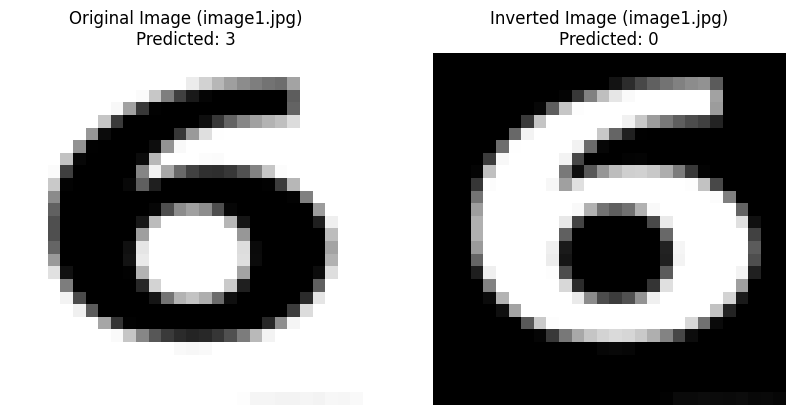

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


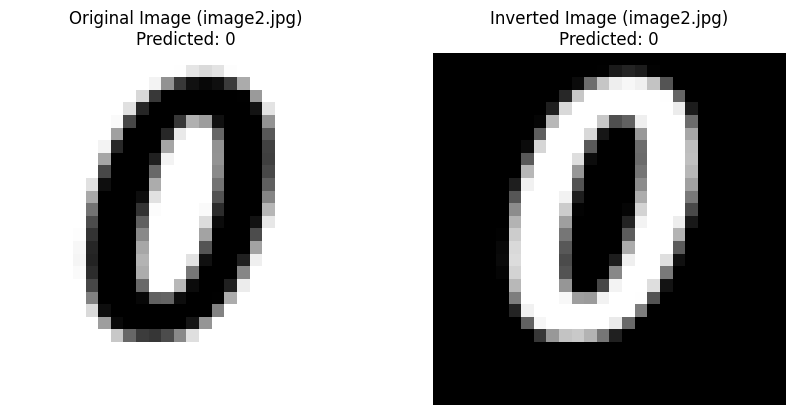

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


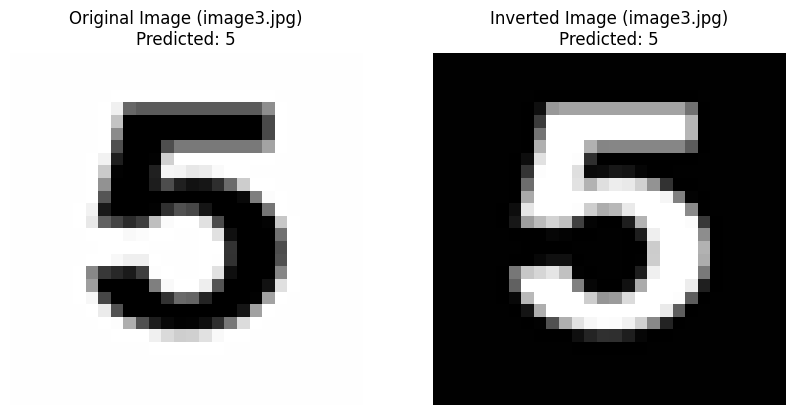

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


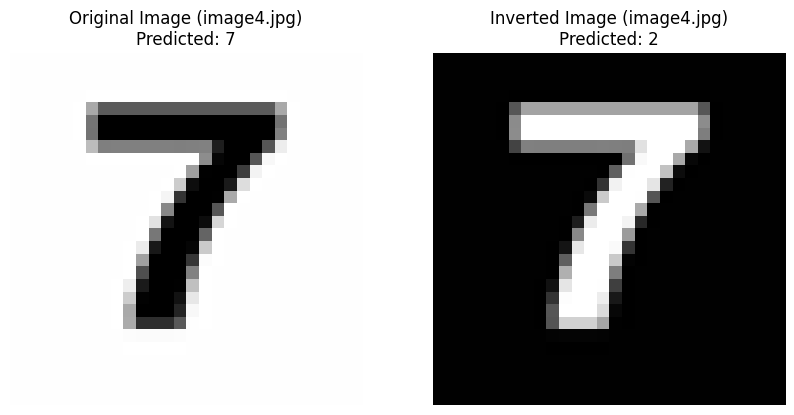

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


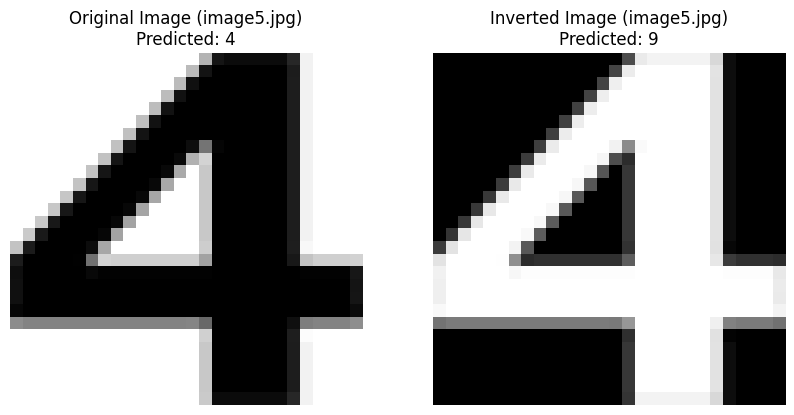

In [27]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define the paths to your images
image_paths = [f'image{i}.jpg' for i in range(1, 6)] # For image1.jpg to image5.jpg

for image_path in image_paths:
    try:
        # Load the image
        img = Image.open(image_path)

        # Convert to grayscale (if not already) and resize to 28x28
        img_gray = img.convert('L').resize((28, 28))

        # Convert image to numpy array and normalize to 0-1 range
        original_image_array = np.array(img_gray, dtype=np.float32) / 255.0

        # Reshape to be [samples][channels][width][height] for model input (channels_first)
        # The models were trained with (1, 28, 28) as input shape (channels, height, width)
        original_image_processed = original_image_array.reshape(1, 1, 28, 28)

        # Invert the image colors (MNIST digits are white on black, so an image of a digit might need inversion)
        # If your image is already black digit on white background, you might not need this.
        inverted_image_processed = 1 - original_image_processed

        # Use one of your trained models, e.g., model_large
        model_to_use = model_large

        # Predict with the original image
        original_prediction_probs = model_to_use.predict(original_image_processed)
        original_predicted_digit = np.argmax(original_prediction_probs)

        # Predict with the inverted image
        inverted_prediction_probs = model_to_use.predict(inverted_image_processed)
        inverted_predicted_digit = np.argmax(inverted_prediction_probs)

        # Display original and inverted images with predictions
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(original_image_processed.reshape(28, 28), cmap=plt.get_cmap('gray'))
        plt.title(f"Original Image ({image_path})\nPredicted: {original_predicted_digit}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(inverted_image_processed.reshape(28, 28), cmap=plt.get_cmap('gray'))
        plt.title(f"Inverted Image ({image_path})\nPredicted: {inverted_predicted_digit}")
        plt.axis('off')

        plt.show()

    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}. Please provide a valid path.")
    except Exception as e:
        print(f"An error occurred processing {image_path}: {e}")